<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Hanna/Lab_Assignment2/Assignment2_Upload.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | First Name | Last Name | Signature | Hours | Contribution |
| Member 2: | First Name | Last Name | Signature | Hours | Contribution |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |



# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

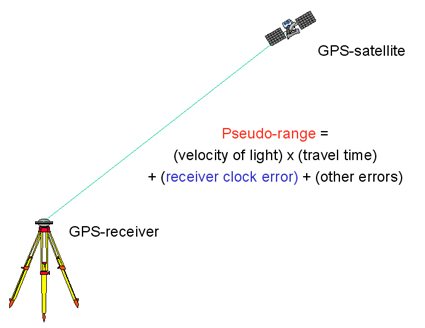

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel('/content/drive/MyDrive/Assignment 2 Data/part1_data/pseudoranges.xlsx')
df_sat_pos = pd.read_excel('/content/drive/MyDrive/Assignment 2 Data/part1_data/satellite_position.xlsx')

np.random.seed(42)  # For reproducible results
pseudorange_array = df_pseudorange.to_numpy()
pseudorange_array[:, 1] += np.random.uniform(0, 0.5, pseudorange_array.shape[0])
sat_pos_array = df_sat_pos.to_numpy()

sat_pos = sat_pos_array[:, 1:4]
pseudorange = pseudorange_array[:, 1]

In [4]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = pseudorange_array.shape[0]
m = 4

print("Number of measurements (n):", n)
print("Number of unknown states (m):", m)

Number of measurements (n): 11
Number of unknown states (m): 4


In [5]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [6]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):
    """
    Compute the geometric distances between satellites and receiver.

    Parameters:
    - receiver_pos (numpy.ndarray): Array of shape (3,), receiver's position -> [x_r, y_r, z_r]
    - satellite_pos (numpy.ndarray): Array of shape (n, 3), positions of satellites -> [[x_s1, y_s1, z_s1], [x_s2, y_s2, z_s2], ..., [x_sn, y_sn, z_sn]]

    Returns:
    - distance (numpy.ndarray): Array of length (n), geometric distances between satellites and receiver.
    """

    return np.linalg.norm(satellite_pos - receiver_pos, axis=1)


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [7]:
P = np.eye(n) * (1/1.2)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [8]:
x_0 = np.array ([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [9]:
delta = np.array([10, 10, 10, 10])
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [10]:
def design_matrix(receiver_pos, satellite_pos, distance):
    """
    Compute the design matrix A for GPS LSE.

    Parameters:
    - receiver_pos: Array of shape (3,)
      The current estimate of the receiver's unknown position [r_x, r_y, r_z].
    - satellite_pos: Array of shape (n, 3)
      The positions of the n satellites [[s_x, s_y, s_z], ...].
    - distance: Array of shape (n,)
      The geometric distances between the satellites and the receiver.

    Returns:
    - A: Array of shape (n,4) -> Design matrix A
    """
    # compute differences between satellite and receiver coordinates
    #(numerator for partial derivatives)
    diff = receiver_pos - satellite_pos # shape (n,3)

    # Initialize design matrix
    A = np.empty((satellite_pos.shape[0], 4))

    # Fill in first 3 columns with partial derivatives with respect to unknown receiver positions.
    A[:, 0] = diff[:, 0] / distance
    A[:, 1] = diff[:, 1] / distance
    A[:, 2] = diff[:, 2] / distance

    # Fill in last column with receiver clock offset constant
    A[:, 3] = -1

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [11]:
while np.linalg.norm(delta[:3]) >= 0.008:

       # compute the geometri distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       receiver_pos = x_hat[:3]
       cdT = x_hat[3]

       distance = euclidean_norm(receiver_pos, sat_pos)

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(receiver_pos, sat_pos, distance)

       # compute the misclosure array w
       # (0.5 marks)
       w = pseudorange - (distance - cdT)

       # compute the corrections delta
       # (0.5 marks)
       delta = np.linalg.pinv(A.T @ P @ A) @ (A.T @ P @ w)

       # update the states
       x_hat = x_hat + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)


       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(w.copy())
       arr_delta.append(delta.copy())
       arr_err_pos.append(err_pos)
       arr_i.append(i)




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
apv = (w.T @ P @ w)/(n-m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.pinv(A.T @ P @ A)



### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [12]:
from IPython.display import display, Math

w_str = " \\\\ ".join([f"{val:.4f}" for val in w])
cov_rows = [" & ".join([f"{val:.6f}" for val in row]) for row in C_x_hat]
cov_matrix = " \\\\ ".join(cov_rows)

display(Math(rf"""
\large \textbf{{Non-Linear LSE Results}} \\[10pt]

\begin{{aligned}}
\textbf{{Estimated Receiver States:}} \\[4pt]
x_r &= {x_hat[0]:.6f} \\
y_r &= {x_hat[1]:.6f} \\
z_r &= {x_hat[2]:.6f} \\
cdT &= {x_hat[3]:.6f} \\
\\[10pt]

\textbf{{Final Corrections:}} \\[4pt]
\Delta x_r &= {delta[0]:.6e} \\
\Delta y_r &= {delta[1]:.6e} \\
\Delta z_r &= {delta[2]:.6e} \\
\Delta cdT &= {delta[3]:.6e} \\
\\[10pt]

\textbf{{Measurement Residuals:}} \\
\mathbf{{w}} &=
\left[
\begin{{matrix}}
{w_str}
\end{{matrix}}
\right] \\
\\[10pt]

\textbf{{A Posterior Variance of Unit Weight:}} \\
\sigma_0^2 &= {apv:.6f} \\
\\[10pt]

\textbf{{Covariance Matrix of Estimated States:}} \\
C_{{\hat x}} &=
\left[
\begin{{matrix}}
{cov_matrix}
\end{{matrix}}
\right] \\
\\[10pt]

\textbf{{Number of Iterations:}} \\
i &= {i} \\
\\[10pt]

\textbf{{Final 3D Position Error:}} \\
\left\lVert \hat{{x}} - x_{{gt}} \right\rVert &= {arr_err_pos[-1]:.6f} \text{{ m}}
\end{{aligned}}
"""))



<IPython.core.display.Math object>

### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [13]:
# The APV of unit weight value is ​≈0.90.
# Because this number is relatively close to 1, this indicates that the residuals fit the model reasonably well and there aren't any majorly impactful errors in the measurements.
# However, since this value is slightly smaller than 1, it indicates that the residuals are smaller than what the assumed observation variances predicted and the assigned weights were too slightly too small and the measurements were actually more precise than predicted.
# The covariance matrix of estimated states indicates the variances (squared error) of x_r, y_r, z_r, and cdT on the diagonal of the matrix (approx. 0.34, 0.46, 2.21, and 0.76, respectively).
# Higher values here indicate greater uncertainty, therfore x and y have good accuracy (less uncertainty), cdT has slight worse accuracy, and z has the highest uncertainty (or accuracy).
# This implies that horizontal components (x,y) are more precisely estimated than the vertical component.
# The off-diagonal values provide information about the correlation of the parameters, with positive values closer to one implying a stronger positive correlation, and negative values closer to -1 implying a stronger negative correlation (values = 0 means no relationship).
# The covariance between z_r and cdT of -1.19 indicates a strong negative relationship between these parameters, indicating they cannot be estimated independently and their uncertainties influence each other.
# Additionally, a moderate negative correlation exists between y_r and z_r (-0.63) indicating these geometric components are also not entirely independent from one another.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

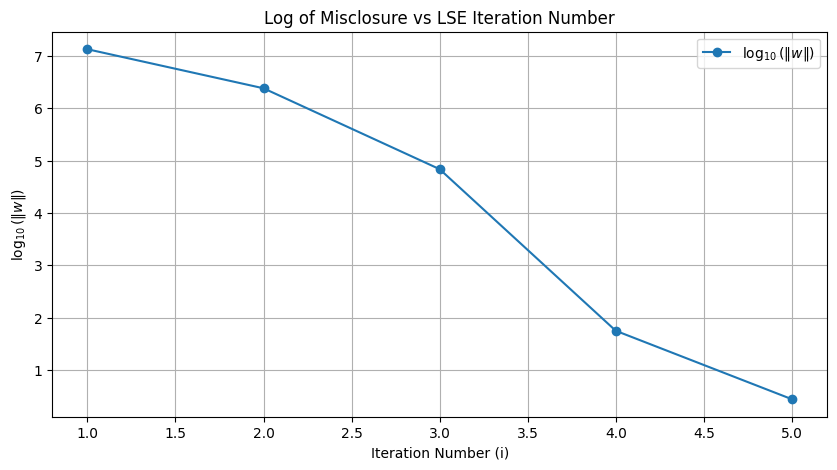

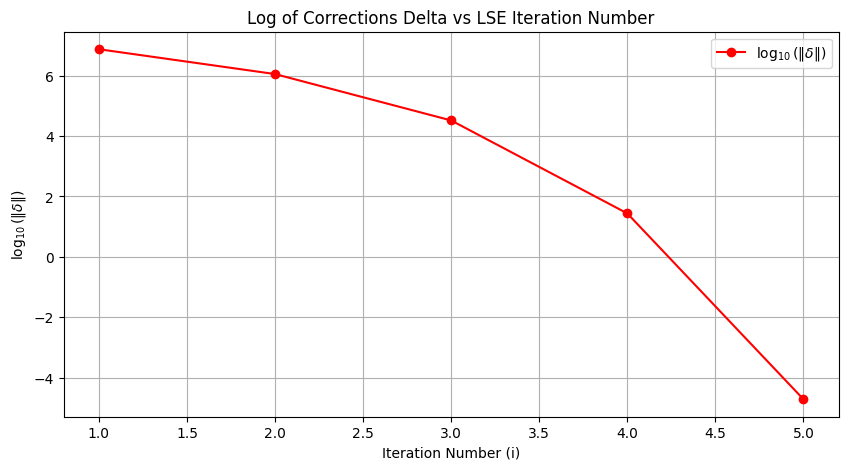

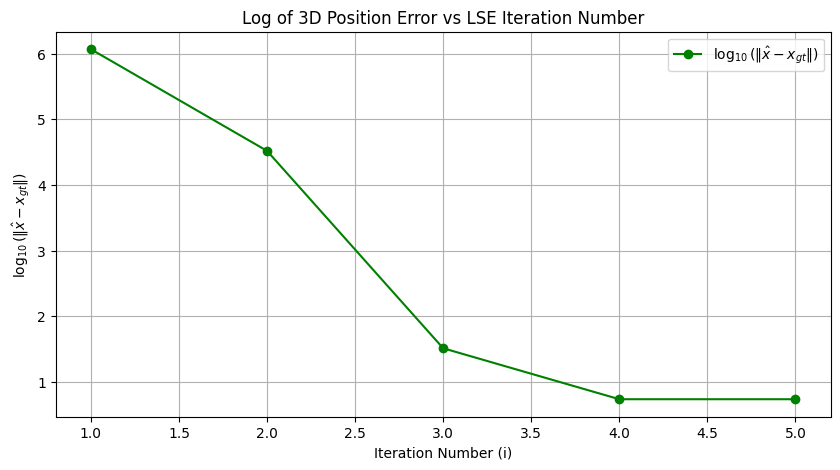

In [14]:
w_norm = np.array([np.linalg.norm(w) for w in arr_w])
delta_norm = np.array([np.linalg.norm(d[:3]) for d in arr_delta])
err_norm = np.array(arr_err_pos)
iters = np.array(arr_i)

# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(10, 5))
plt.plot(iters, np.log10(w_norm), marker = 'o', label=r'$\log_{10}(\|w\|)$')
plt.xlabel('Iteration Number (i)')
plt.ylabel(r'$\log_{10}(\|w\|)$')
plt.title('Log of Misclosure vs LSE Iteration Number')
plt.grid(True)
plt.legend()
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(10, 5))
plt.plot(iters, np.log10(delta_norm), marker='o', color='red', label=r'$\log_{10}(\|\delta\|)$')
plt.xlabel('Iteration Number (i)')
plt.ylabel(r'$\log_{10}(\|\delta\|)$')
plt.title('Log of Corrections Delta vs LSE Iteration Number')
plt.grid(True)
plt.legend()
plt.show()

# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)
plt.figure(figsize=(10, 5))
plt.plot(iters, np.log10(err_norm), marker='o', color='green', label=r'$\log_{10}(\|\hat{x} - x_{gt}\|)$')
plt.xlabel('Iteration Number (i)')
plt.ylabel(r'$\log_{10}(\|\hat{x} - x_{gt}\|)$')
plt.title('Log of 3D Position Error vs LSE Iteration Number')
plt.grid(True)
plt.legend()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [15]:
# 1. Log of misclosure
# The misclosure decreases steadily by several orders of magnitude across the iterations.
# The largest drop occurs between iterations 3 and 4, where the error drops by over 3 orders of magnitude.
# After that, the slope decreases between iterations 4 and 5.
# The misclosure (w) represents the difference between the observed and predicted values, indicating the consistency of the current linearized model with the measured pseudoranges.
# The large initial w indicates the initial linearization is poor, and the design matrix A does not accurately repesent the function.
# Each subsequent iteration shows an improved linearization.
# Between iterations 4 and 5, the magnitude of change decreases relative to all previous iterations.
# The flattening indicates the linearization has approched the true pseudorange function.

# 2. Log of corrections delta
# The corrections vector magnitude decreases at every iteration, with the largest magnitude in change between the 4th and 5th iterations.
# This delta tells us how much the estimated receiver position changes at each iteration.
# The size of delta also depends on the magnitude of misclosure vector.
# The corrections delta is large initially when w remains large and the continued large-magnitude decreases in corrections indicate linearization and receiver position estimates are still poor.
# By interations 4-5, the corrections delta becomes much smaller, indicating only minor changes to estimates of receiver positions.
# Because change in estimation corrections decreases, it indicates greater accuracy in estimates and the design matrix A.

# 3. Log of 3D position error
# Position error magnitude decreases sharply between iterations 1-3, and less rapidly between iterations 3-4 and plateaus after iteration 4.
# After each iteration, the linearized approximation improves, and better represents the true receiver position.
# When the 3D position error plateaus, it indicated that further improvements to the model will not improve the receiver position estimates.
# The position error does not reach 0 likely due to noise, or fundamental properties of how measurements were taken.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [16]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [17]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
  """
  Compute the cost function for GPS LSE (sum of squared residuals between measured and predicted pseudoranges).

  Parameters:
  - rec_pos: Array of shape (3,), positions of receiver
  - cdT: Clock offset
  - sat_pos: Array of shape (n, 3), positions of satellites
  - pseudorange: Array of shape (n,), measured pseudoranges

  Returns:
  - cost function: scalar, sum of squared residuals
  """
  rho = euclidean_norm(rec_pos, sat_pos)

  predicted = rho - cdT

  residuals = pseudorange - predicted

  L = np.sum(residuals**2)

  return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [18]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    """
    Compute the gradient of the cost function for wrt [x_r, y_r, z_r, cdT].

    Parameters:
    - rec_pos: Array of shape (3,), positions of receiver
    - cdT: Clock offset
    - sat_pos: Array of shape (n, 3), positions of satellites
    - pseudorange: Array of shape (n,), measured pseudoranges
    Returns:
    - gradient: Array of shape (4,), gradient vector
    """

    geom_distance = euclidean_norm(rec_pos, sat_pos)

    predicted = geom_distance - cdT

    residuals = pseudorange - predicted

    # Build design matrix A
    A = np.zeros((len(sat_pos), 4))
    diff = rec_pos - sat_pos

    # Partial derivatives wrt receiver coords
    diff = rec_pos - sat_pos
    A[:, 0] = diff[:, 0]/geom_distance
    A[:, 1] = diff[:, 1]/geom_distance
    A[:, 2] = diff[:, 2]/geom_distance

    # Partial derivative wrt cdT
    A[:, 3] = -1

    # Gradient formula Gradient L = 2 At r
    grad = -2 * A.T @ residuals

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [19]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [20]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# Final estimated position
x_r, y_r, z_r, cdT = optimized_params

# Compute final position errors
final_position_error_vector = optimized_params[:3] - GroundTruth

# Final position error norm
final_position_error_norm = np.linalg.norm(final_position_error_vector)

# Compute final cost value
final_cost = cost_function(
    optimized_params[:3],
    optimized_params[3],
    sat_pos,
    pseudorange
)

# Compute the final gradient vector
final_grad = gradient(
    optimized_params[:3],
    optimized_params[3],
    sat_pos,
    pseudorange
)

# Final gradient norm
final_grad_norm = np.linalg.norm(final_grad)

# print the metrics
# (1 marks)
from IPython.display import display, Math

err_vec_str = " \\\\ ".join([f"{val:.6f}" for val in final_position_error_vector])
grad_vec_str = " \\\\ ".join([f"{val:.6f}" for val in final_grad])

display(Math(rf"""
\large \textbf{{Gradient Descent Optimization Results - Default Hyperparameter}} \\[10pt]

\begin{{aligned}}
\textbf{{Optimized Parameters:}} \\[4pt]
x_r &= {optimized_params[0]:.6f} \\
y_r &= {optimized_params[1]:.6f} \\
z_r &= {optimized_params[2]:.6f} \\
cdT &= {optimized_params[3]:.6f} \\
\\[10pt]

\textbf{{Final Position Error Vector:}} \\
\Delta \mathbf{{x}} &=
\left[
\begin{{matrix}}
{err_vec_str}
\end{{matrix}}
\right] \\
\\[6pt]

\textbf{{Final Position Error Norm:}} \\
\left\lVert \hat{{x}} - x_{{gt}} \right\rVert &= {final_position_error_norm:.6f} \text{{ m}} \\
\\[10pt]

\textbf{{Number of Iterations to Converge:}} \\
i &= {steps_count} \\
\\[10pt]

\textbf{{Final Cost Value:}} \\
L &= {final_cost:.6f} \\
\\[10pt]

\textbf{{Final Gradient Vector:}} \\
\nabla L &=
\left[
\begin{{matrix}}
{grad_vec_str}
\end{{matrix}}
\right] \\
\\[6pt]

\textbf{{Final Gradient Norm:}} \\
\left\lVert \nabla L \right\rVert &= {final_grad_norm:.6e}
\end{{aligned}}
"""))

<IPython.core.display.Math object>

### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

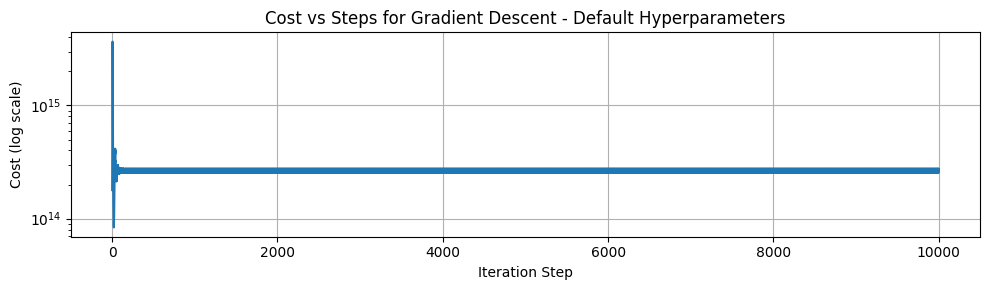

In [21]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(arr_cost)
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Cost (log scale)')
ax.set_title('Cost vs Steps for Gradient Descent - Default Hyperparameters')
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The cost begins at a very high value and drops sharply within the very first few steps. After this initial change, the cost 'flatlines' at a high magnitude (10^14) across all iterations.
# There is no visible trend, consistent with the algorithm reporting i = 0, meaning the gradient descent never performed a successful update step.
# Because the learning rate (alpha) was too large for the curvature of the function, the first update step was too big, and the algorithm overshot the region where the cost function decreases smoothly.
# The cost function lands in a region where the cost function is still large, so it takes no steps towards the cost function close to the "bowl" or "valley" and instead remains large.
# Since the new cost and current cost are similarly large this causes the convergence condition |new_cost-current_cost| < tolerance to become true on the very first iteration, so the algorithm stops immediately.
# As a result, the solver reports i = 0 iterations despite not actually reaching convergence.


### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

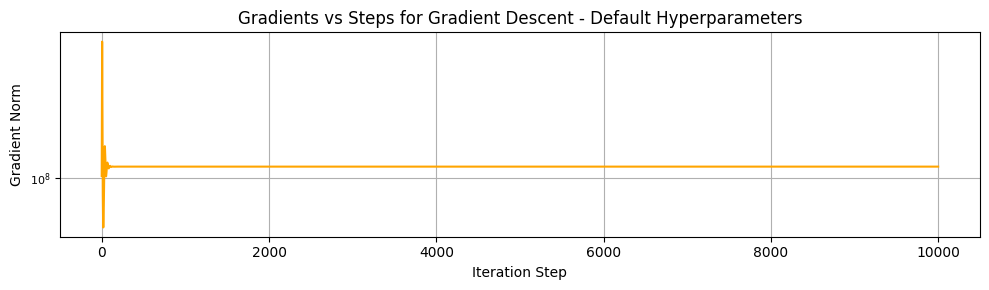

In [22]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grad_norms = [np.linalg.norm(g) for g in arr_grad]

ax.plot(grad_norms, label='Gradients', color='orange')
ax.set_yscale('symlog')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradients vs Steps for Gradient Descent - Default Hyperparameters')

ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# Similar to the cost vs steps plot, the gradients spike at a very high value and drops sharply within the very first few steps, before flat lining at a high magnitude (around 10^8)
# Because the gradient norm overshoots the region where the function gradually/smoothly decreases and lands on a region where cost remains high, triggering the stopping condition.
# Because the stopping condition is triggered (due to the small difference in large new/current costs), the gradient descent is terminated and does not reduce the gradient any futher, causing the flatline.

### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

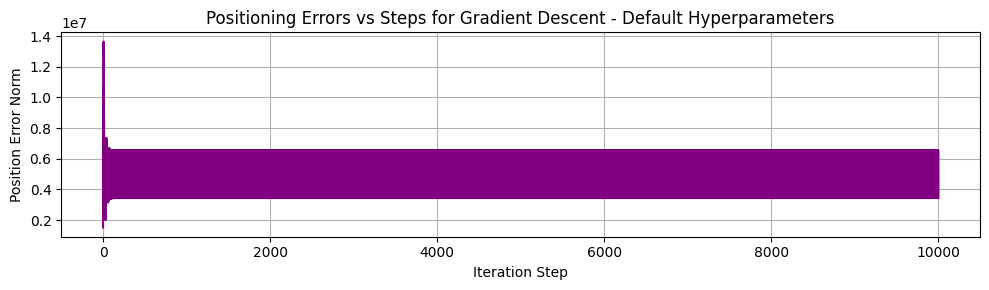

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
pos_error_norms = [np.linalg.norm(err) for err in arr_err]

ax.plot(pos_error_norms, label='Position Errors', color='purple')
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Position Error Norm')
ax.set_title('Positioning Errors vs Steps for Gradient Descent - Default Hyperparameters')
ax.grid(True)
fig.tight_layout()
plt.show()

# Comment on the pattern
# (0.5 marks)
# Similar to the previous plots, the positioning error begins extremely large with an initial spike ~14 million meters. After this, the error drops slightly settles into a long plateau between rougly 2.5e6 meters and 6e6 meters.
# Because the position error does not decreace toward an improved accuracy for the 3D position estimate, the error remains in the multi-million-meter range for the entire run, indicating the gradient descent makes no progress in reducing the position error.
# Again because the learning rate is too large, the algorithm is stuck at i=0 and the gradient never descends.
# As a result the estimated receiver position never moves closer to the true position, and the error remains extremely large.

### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [24]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(
    pseudorange,
    sat_pos,
    learning_rate=0.008,
    max_iters=20000,
    tolerance=8e-7
    )
# Final estimated position
x_r2, y_r2, z_r2, cdT2 = optimized_params_2

# Compute final position errors
final_position_error_vector_2 = optimized_params_2[:3] - GroundTruth

# Final position error norm
final_position_error_norm_2 = np.linalg.norm(final_position_error_vector_2)

# Compute final cost value
final_cost_2 = cost_function(
    optimized_params_2[:3],
    optimized_params_2[3],
    sat_pos,
    pseudorange
)

# Compute the final gradient vector
final_grad_2 = gradient(
    optimized_params_2[:3],
    optimized_params_2[3],
    sat_pos,
    pseudorange
)

# Final gradient norm
final_grad_norm_2 = np.linalg.norm(final_grad_2)

# print the metrics
# (1 marks)
from IPython.display import display, Math

err_vec_str_2 = " \\\\ ".join([f"{val:.6f}" for val in final_position_error_vector_2])
grad_vec_str_2 = " \\\\ ".join([f"{val:.6f}" for val in final_grad_2])

display(Math(rf"""
\large \textbf{{Gradient Descent Optimization Results (Learning Rate = 0.008)}} \\[10pt]

\begin{{aligned}}
\textbf{{Optimized Parameters:}} \\[4pt]
x_r &= {optimized_params_2[0]:.6f} \\
y_r &= {optimized_params_2[1]:.6f} \\
z_r &= {optimized_params_2[2]:.6f} \\
cdT &= {optimized_params_2[3]:.6f} \\
\\[10pt]

\textbf{{Final Position Error Vector:}} \\
\Delta \mathbf{{x}} &=
\left[
\begin{{matrix}}
{err_vec_str_2}
\end{{matrix}}
\right] \\
\\[6pt]

\textbf{{Final Position Error Norm:}} \\
\left\lVert \hat{{x}} - x_{{gt}} \right\rVert &= {final_position_error_norm_2:.6f} \text{{ m}} \\
\\[10pt]

\textbf{{Number of Iterations to Converge:}} \\
i &= {steps_count} \\
\\[10pt]

\textbf{{Final Cost Value:}} \\
L &= {final_cost_2:.6f} \\
\\[10pt]

\textbf{{Final Gradient Vector:}} \\
\nabla L &=
\left[
\begin{{matrix}}
{grad_vec_str_2}
\end{{matrix}}
\right] \\
\\[6pt]

\textbf{{Final Gradient Norm:}} \\
\left\lVert \nabla L \right\rVert &= {final_grad_norm_2:.6e}
\end{{aligned}}
"""))

Converged !


<IPython.core.display.Math object>

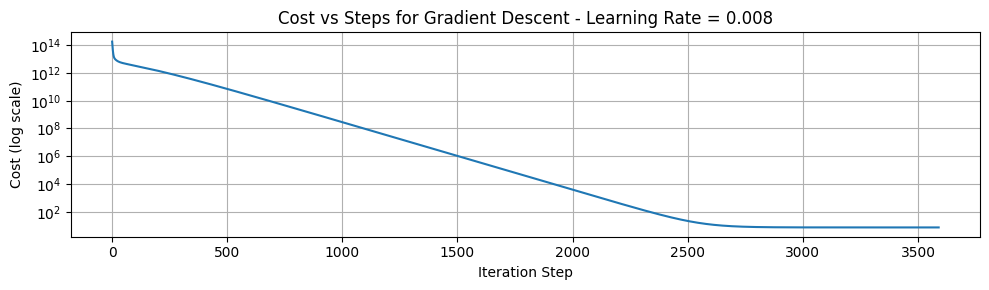

In [25]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(arr_cost)
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Cost (log scale)')
ax.set_title('Cost vs Steps for Gradient Descent - Learning Rate = 0.008')
ax.grid(True)
fig.tight_layout()
plt.show()

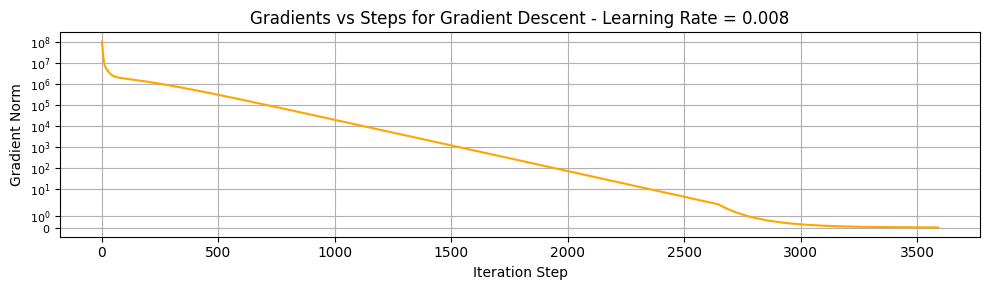

In [26]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grad_norms_2 = [np.linalg.norm(g) for g in arr_grad]

ax.plot(grad_norms_2, label='Gradients', color='orange')
ax.set_yscale('symlog')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradients vs Steps for Gradient Descent - Learning Rate = 0.008')

ax.grid(True)
fig.tight_layout()
plt.show()

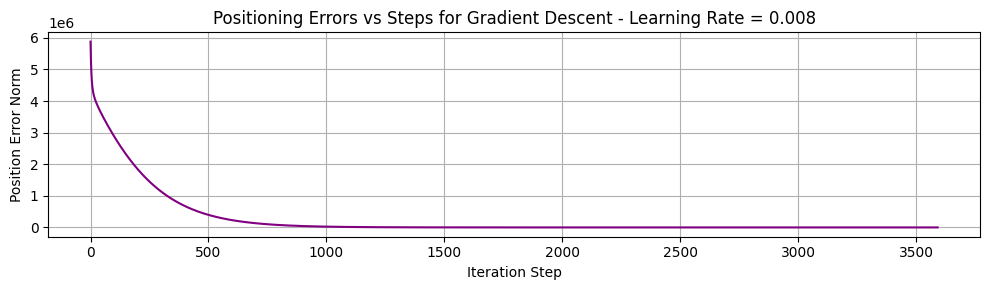

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
pos_error_norms_2 = [np.linalg.norm(err) for err in arr_err]

ax.plot(pos_error_norms_2, label='Position Errors', color='purple')
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Position Error Norm')
ax.set_title('Positioning Errors vs Steps for Gradient Descent - Learning Rate = 0.008')
ax.grid(True)
fig.tight_layout()
plt.show()

In [28]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(
    pseudorange,
    sat_pos,
    learning_rate=0.0008,
    max_iters=50000,
    tolerance=8e-7
    )
# Final estimated position
x_r3, y_r3, z_r3, cdT3 = optimized_params_3

# Compute final position errors
final_position_error_vector_3 = optimized_params_3[:3] - GroundTruth

# Final position error norm
final_position_error_norm_3 = np.linalg.norm(final_position_error_vector_3)

# Compute final cost value
final_cost_3 = cost_function(
    optimized_params_3[:3],
    optimized_params_3[3],
    sat_pos,
    pseudorange
)

# Compute the final gradient vector
final_grad_3 = gradient(
    optimized_params_3[:3],
    optimized_params_3[3],
    sat_pos,
    pseudorange
)

# Final gradient norm
final_grad_norm_3 = np.linalg.norm(final_grad_3)

# print the metrics
# (1 marks)
from IPython.display import display, Math

err_vec_str_3 = " \\\\ ".join([f"{val:.6f}" for val in final_position_error_vector_3])
grad_vec_str_3 = " \\\\ ".join([f"{val:.6f}" for val in final_grad_3])

display(Math(rf"""
\large \textbf{{Gradient Descent Optimization Results (Learning Rate = 0.0008)}} \\[10pt]

\begin{{aligned}}
\textbf{{Optimized Parameters:}} \\[4pt]
x_r &= {optimized_params_3[0]:.6f} \\
y_r &= {optimized_params_3[1]:.6f} \\
z_r &= {optimized_params_3[2]:.6f} \\
cdT &= {optimized_params_3[3]:.6f} \\
\\[10pt]

\textbf{{Final Position Error Vector:}} \\
\Delta \mathbf{{x}} &=
\left[
\begin{{matrix}}
{err_vec_str_3}
\end{{matrix}}
\right] \\
\\[6pt]

\textbf{{Final Position Error Norm:}} \\
\left\lVert \hat{{x}} - x_{{gt}} \right\rVert &= {final_position_error_norm_3:.6f} \text{{ m}} \\
\\[10pt]

\textbf{{Number of Iterations to Converge:}} \\
i &= {steps_count} \\
\\[10pt]

\textbf{{Final Cost Value:}} \\
L &= {final_cost_3:.6f} \\
\\[10pt]

\textbf{{Final Gradient Vector:}} \\
\nabla L &=
\left[
\begin{{matrix}}
{grad_vec_str_3}
\end{{matrix}}
\right] \\
\\[6pt]

\textbf{{Final Gradient Norm:}} \\
\left\lVert \nabla L \right\rVert &= {final_grad_norm_3:.6e}
\end{{aligned}}
"""))

Converged !


<IPython.core.display.Math object>

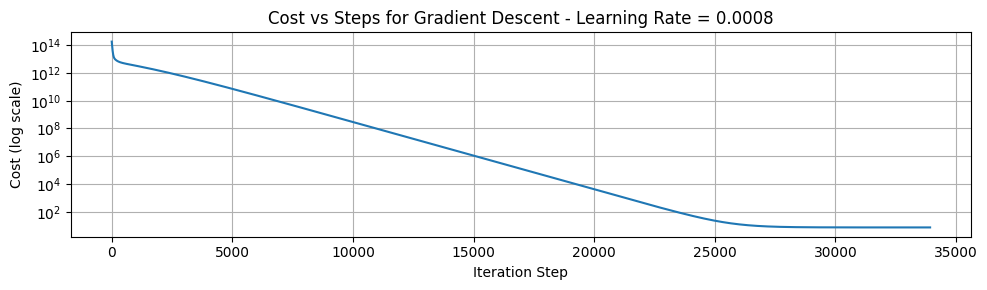

In [29]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
ax.semilogy(arr_cost)
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Cost (log scale)')
ax.set_title('Cost vs Steps for Gradient Descent - Learning Rate = 0.0008')
ax.grid(True)
fig.tight_layout()
plt.show()

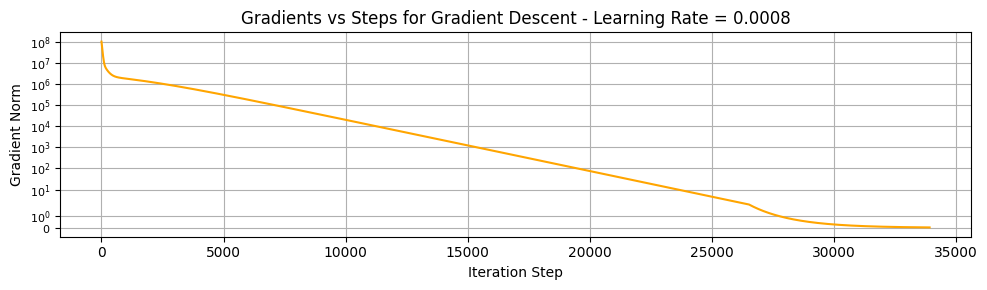

In [30]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)
grad_norms_3 = [np.linalg.norm(g) for g in arr_grad]

ax.plot(grad_norms_3, label='Gradients', color='orange')
ax.set_yscale('symlog')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Gradient Norm')
ax.set_title('Gradients vs Steps for Gradient Descent - Learning Rate = 0.0008')

ax.grid(True)
fig.tight_layout()
plt.show()

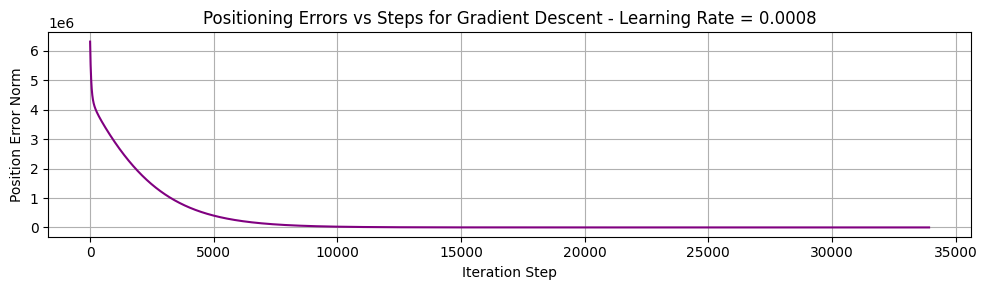

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
# (0.5 marks)
pos_error_norms_3 = [np.linalg.norm(err) for err in arr_err]

ax.plot(pos_error_norms_3, label='Position Errors', color='purple')
ax.set_xlabel('Iteration Step')
ax.set_ylabel('Position Error Norm')
ax.set_title('Positioning Errors vs Steps for Gradient Descent - Learning Rate = 0.0008')
ax.grid(True)
fig.tight_layout()
plt.show()

### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [32]:
# your answer here
#Q1
# Changing the learning rate dramatically impacted the behaviour of the gradient descent. With the default learning rate, the algorithm failed to take a single stable update step: the gradients stayed extremely large, the cost flat-lined at a very high value, and the 3D position error remained in the multi-million-meter range.
# Because the step size was so large, the first update overshot the minimum and landed on an unstable region of the cost function.
# After reducing the learning rate to 0.008, the gradient descent was behaved more appropriately.
# The gradients and cost both steadily decreased, and the position errors showed a smooth decreasing curve rather than the wide error-band seen before.
# The smaller learning rate prevented overshooting and allowed the algorithm to move gradually toward the minimum.
# These results highlight gradient descent is very sensitive to learning rate and that choosing a value suited to the data is important to achieve convergence, rather than divergence.
# Between using a learning rate of 0.008 and 0.0008, the positioning errors and final cost values have negligible differences.
#This means that both algorithms reached essentially the same minimum and 3D position estimates - both of which were very accurate.
# Because using a learning rate of 0.0008 achieved extremely similar results, but required 33,936 iterations, it is more favourable to use a learning rate of 0.008 (i = 3,591) to spare computational cost.
# In other cases, for example where data has statistical variability, using the smaller learning rate could potentially contribute to overfitting.

#Q2
# The nonlinear LSE method converged quickly (in only 5 iterations), and produced an accurate receiver position with a small final error.
# By incorporating the design matrix and solving a linerized-least squares system at each iteration, each update accounts for the curvature/geometry of the problem and can move estimates efficiently towards the true solution.
# Gradient descent, relies only on the negative gradient direction and a fixed learning-rate, meaning it does not use curvature of geometric information relavent to the problem.
# As a result, the gradient descent was sensitive to user-inputted hyperparameter choice.
# With the default learning rate, it diverged completely, and even after reaching convergence by adjusting learning rate, it required a thousands of iterations.
# Despite requiring significantly more iterations, gradient descent achieved essentially the same results as LSE.
# The small differences in position error between 5.43 m (LSE), 5.42 m (GD alpha = 0.008), and 5.39 (GD alpha = 0.0008) highlight LSE's capabilities in reaching the same error level much more efficiently.
# For this problem and datatset, LSE was faster and more stable while gradient descent was slower, less reliable and highly dependent on choice of learning rate.
# In other cases where data is highly dimensional, the design matrix cannot be computed, or you do not have access the all the data at once, gradient descent could be the more reasonable choice.


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('')

# Basic data preprocessing
data.drop(   )  # Remove irrelevant ID column
data.dropna(   )  # Remove rows with missing values
data.drop_duplicates(   )  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
# your code here


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
# your code here


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y =  # Target vector
X =  # Feature matrix

# Display sizes of X and y
# your code here

### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

In [ ]:
# Check the class distribution of y


# Display exact values for each bin in the histogram
# hint: Use for loop
# your code here


plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)


# Display sizes of X_small and y_small (0.5 marks)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(data_tuple):

    # your code here

    return X_train, X_test, y_train, y_test

# Test 1: Full dataset (X and y)

# Test 2: Only first two columns of X and y

# Test 3: Small dataset (X_small and y_small)

print(results)

### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set



In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)



# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel(   )
plt.ylabel(   )
plt.title(   )
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

models = {

}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model


    # Make predictions


    # Calculate accuracy


    # Print results



In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)






plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

### Answer here (double click)


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = pd.read_csv('/content/drive/MyDrive/Assignment 2 Data/part3-data/mnist_train.csv')
test_csv_path = pd.read_csv('/content/drive/MyDrive/Assignment 2 Data/part3-data/mnist_test.csv')

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = train_csv_path.values
y_train = train_data[:, 0]
X_train = train_data[:, 1:]

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = test_csv_path.values
y_test = test_data[:, 0]
X_test = test_data[:, 1:]

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


Let's visualize some sample images to understand what our models will be learning from.

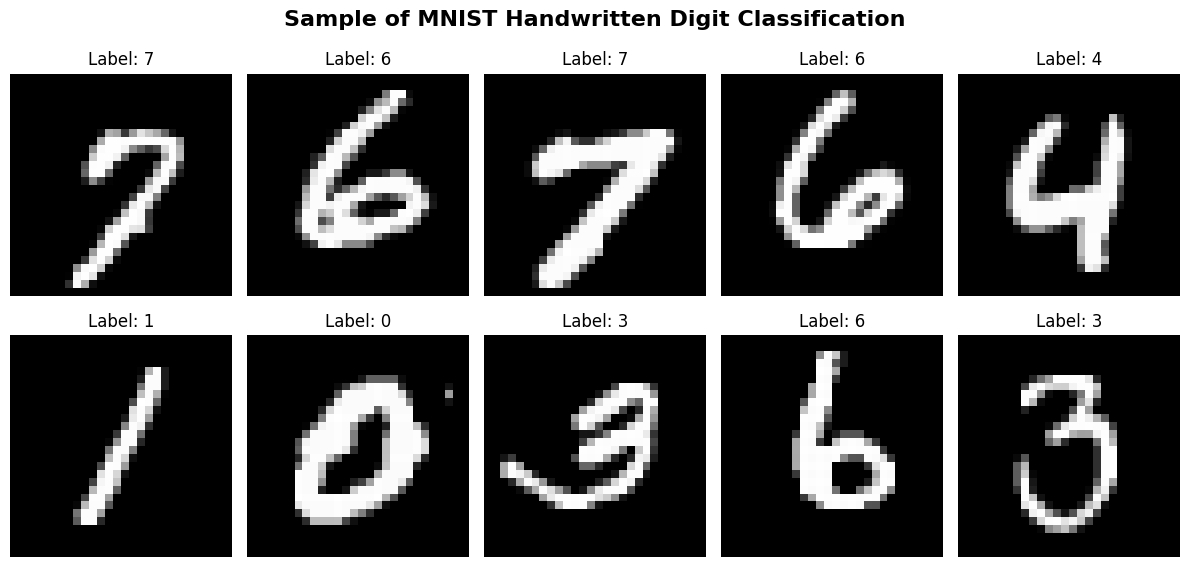

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample of MNIST Handwritten Digit Classification', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255
X_test_normalized = X_test / 255

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
y_train_categorical = to_categorical(y_train, num_classes = 10)
y_test_categorical = to_categorical(y_test, num_classes = 10)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape = (28,28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation = 'relu'), #relu = Rectified Linear Unit

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation = 'relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
        tf.keras.layers.Dense(10, activation = 'softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(X_train_normalized, y_train_categorical, epochs=EPOCHS,
                            batch_size=BATCH_SIZE, validation_split=0.1, verbose=0)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3,3), activation = 'relu'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2,2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2,2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(10, activation = 'softmax')
])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    #Optimizer determines how the model updates its weights based on the gradients
    #Loss Function measures how far the predicted outputs are from the true labels, labels are one-hot encoded
    #Metrics, what to monitor during training and evaluation, tracking accuracy
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(X_train_normalized, y_train_categorical, epochs = EPOCHS) #epoch = one complete pass through all training samples, how many times dataset passed through model

print("CNN training completed")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.8939 - loss: 0.3438
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9854 - loss: 0.0485
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9896 - loss: 0.0321
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9920 - loss: 0.0258
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9943 - loss: 0.0193
CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test_normalized, y_test_categorical)
mlp_predictions = mlp_model.predict(X_test_normalized)
mlp_predicted_classes = np.argmax(mlp_predictions, axis = 1)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_normalized, y_test_categorical)
cnn_predictions = cnn_model.predict(X_test_normalized)
cnn_predicted_classes = np.argmax(cnn_predictions, axis = 1)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results
print(f"MLP Loss: {mlp_loss}")
print(f'MLP Accuracy: {mlp_accuracy}')
print(f'MLP Prediction: {mlp_predicted_classes}')

print(f"CNN Loss: {cnn_loss}")
print(f'CNN Accuracy: {cnn_accuracy}')
print(f'CNN Prediction: {cnn_predicted_classes}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9717 - loss: 0.0967
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9812 - loss: 0.0635
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
MLP Loss: 0.08488103747367859
MLP Accuracy: 0.9750999808311462
MLP Prediction: [7 2 1 ... 4 5 6]
CNN Loss: 0.05533921346068382
CNN Accuracy: 0.9840999841690063
CNN Prediction: [7 2 1 ... 4 5 6]


Performance comparison visualization

MLP Accuracy: 96.53703570365906
CNN Accuracy: 99.40833449363708


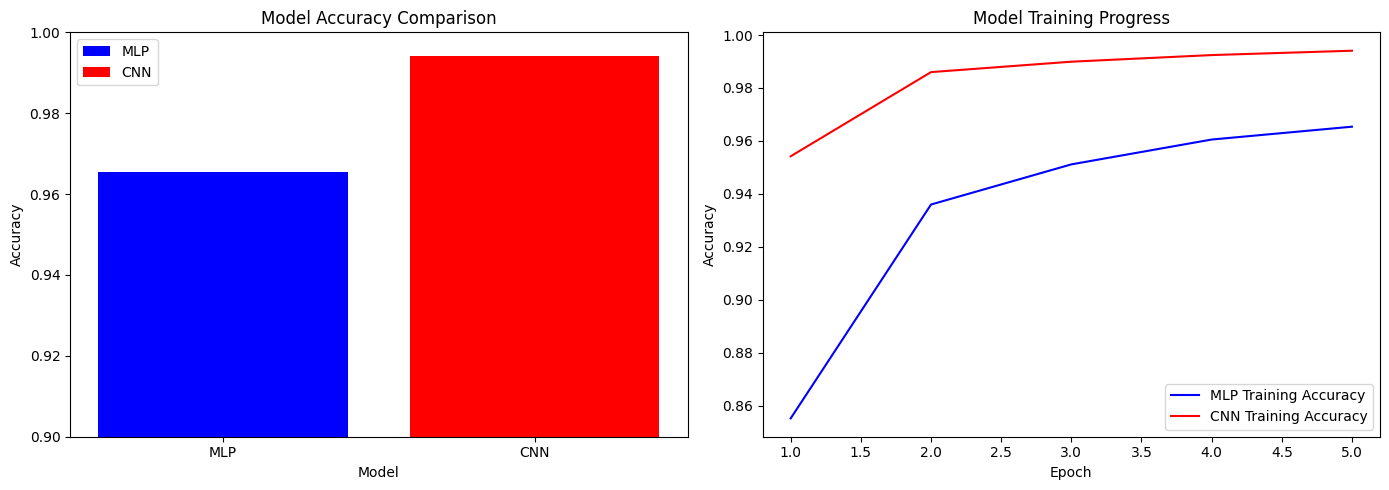

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step
mlp_accuracy = mlp_history.history['accuracy']
cnn_accuracy = cnn_history.history['accuracy']

fig, axes = plt.subplots(1, 2, figsize= (14, 5))

#Bar Chart
axes[0].bar('MLP', mlp_accuracy[-1], color = 'blue')
axes[0].bar('CNN', cnn_accuracy[-1], color ='red')

axes[0].set_ylim([0.90, 1.0]) #Set limits between 90-100% because they were so close in value/accuracy, was hard to read with a 0-100% range
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].legend(['MLP','CNN'])

print(f"MLP Accuracy: {mlp_accuracy[-1]*100}")
print(f"CNN Accuracy: {cnn_accuracy[-1]*100}")

#Line Plot
epochs = range(1, len(mlp_accuracy) +1)

axes[1].plot(epochs, mlp_accuracy, label = 'MLP Training Accuracy', color = 'blue')
axes[1].plot(epochs, cnn_accuracy, label = 'CNN Training Accuracy', color = 'red')

axes[1].set_title('Model Training Progress')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

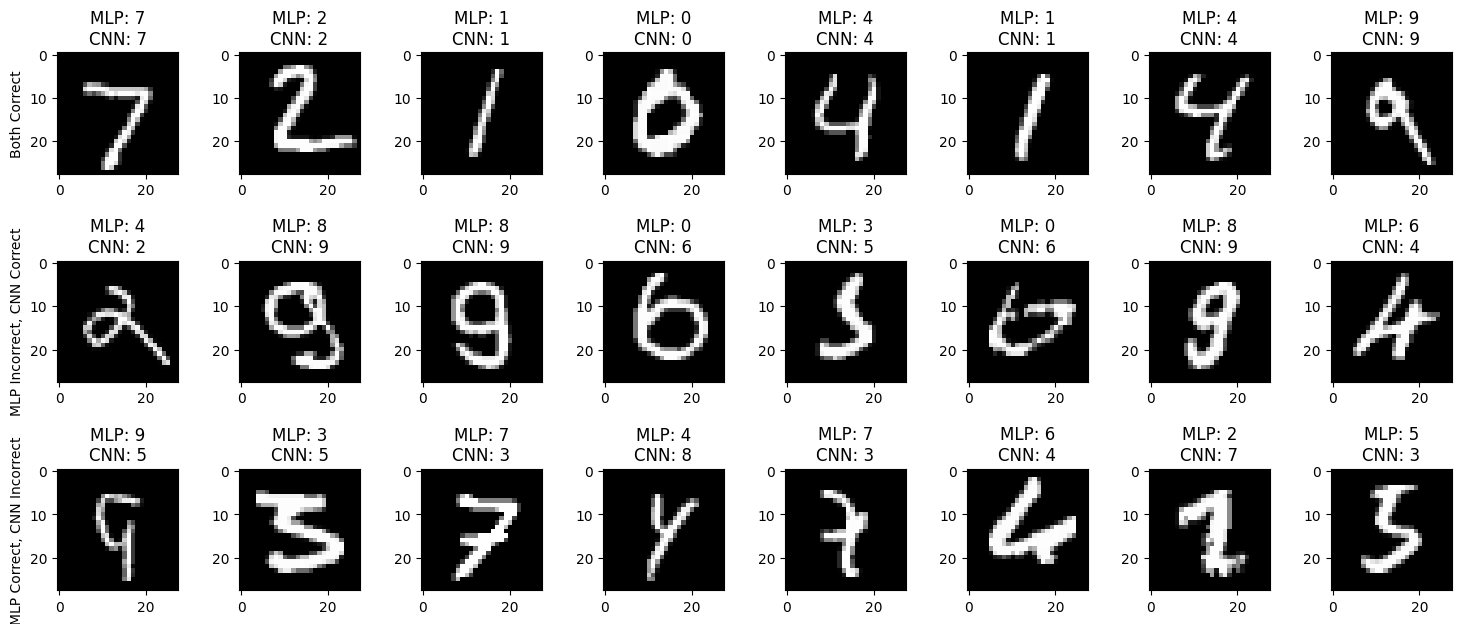

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize= (18, 7))
plt.subplots_adjust(wspace = 0.5, hspace = 0.7)

# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)

# Second row: CNN correct, MLP wrong
cnn_correct_mlp_incorrect = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_incorrect_indices = np.where(cnn_correct_mlp_incorrect)[0][:8]

# Third row: MLP correct, CNN wrong
mlp_correct_cnn_incorrect = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_incorrect_indices = np.where(mlp_correct_cnn_incorrect)[0][:8]

# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

#For Both Correct
for i, idx in enumerate(both_correct_indices):
  axes[0, i].imshow(X_test[idx], cmap='gray')
  axes[0, i].set_title(f"MLP: {mlp_predicted_classes[idx]}\nCNN: {cnn_predicted_classes[idx]}")
  axes[0, 0].set_ylabel("Both Correct", fontsize = 10)

#For CNN Correct, MLP Incorrect
for i, idx in enumerate(cnn_correct_mlp_incorrect_indices):
  axes[1, i].imshow(X_test[idx], cmap='gray')
  axes[1, i].set_title(f"MLP: {mlp_predicted_classes[idx]}\nCNN: {cnn_predicted_classes[idx]}")
  axes[1, 0].set_ylabel("MLP Incorrect, CNN Correct", fontsize = 10)

#For MLP Correct, CNN Incorrect
for i, idx in enumerate(mlp_correct_cnn_incorrect_indices):
  axes[2, i].imshow(X_test[idx], cmap='gray')
  axes[2, i].set_title(f"MLP: {mlp_predicted_classes[idx]}\nCNN: {cnn_predicted_classes[idx]}")
  axes[2, 0].set_ylabel("MLP Correct, CNN Incorrect", fontsize = 10)


plt.show()


## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)

1. The CNN model performed better. First in step 6 we evaluated the models performance on a Test Set (10,000 samples), yielding the CNN model an accuracy of 98.41% and the MLP model an accuracy of 97.51%.
Secondly in step 6, we compared their performance with visualizations (60,000 training samples). The MLP model was 96.53% accurate while the CNN models accuracy was 99.41%. The CNN is specifically designed to specialized in image processing, thus achieving a higher accuracy on image data and a better performance than the MLP.

2. The training curves for both models are somewhat similar in shape, such that both have a steep incline and then flatten out as learning slows. However, the CNN reaches a higher accuracy than the MLP, thus having its curve above the MLP model shows that it is better at extracting features from images.

3. The accuracy improvement percentage tells us that, when given a large data set, a model is able to correctly proccess all of the given image data. A small increase in accuracy leads to a more significant amount of correctly identifed image data. In this case, the CNN was able to correctly proccess more images out of the 60,000 training samples because it achieved a higher accuracy compared to the MLP model.

4. An epoch is one complete pass of the entire image data set through the model it is training. In this section there were 5 epochs for 60,000 trained images, meaning this model saw each image 5 times while learning the image data. We did not need many epochs because the data set was relatively simple, when training the model was able to pick up on the images relatively quick. The model did not have to learn very complex features so running through the traning set 5 times was enough to achieve high accuracy in the model.

5. If given more complex images we would need to add more epochs to process the more detailed image data. We would also continue using the CNN model for processing the more complex images, the CNN model is specifically designed for higher-level spatial features and outperforms the MLP on complex image data.
